# 🏨 Hotel Booking Cancellation Prediction

This project predicts whether a hotel booking will be cancelled using machine learning.
We perform data cleaning, exploratory data analysis (EDA), feature engineering, and train two ML models — Logistic Regression and Random Forest.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [2]:
df = pd.read_csv("hotel_booking.csv")
print("Shape:", df.shape)
df.head()

Shape: (119390, 36)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


## 3. Exploratory Data Analysis

In [3]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [4]:
# Check missing values
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [5]:
# Data types
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

## 4. Data Cleaning

In [6]:
# Fill missing values
df['children'].fillna(0, inplace=True)
df['country'].fillna('unknown', inplace=True)

# Drop columns with too many nulls or irrelevant columns
df.drop(['company', 'agent'], axis=1, inplace=True)

# Drop PII columns
df.drop(['name', 'email', 'phone-number', 'credit_card'], axis=1, inplace=True)

# Convert date column
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

# Drop reservation_status to avoid data leakage
if 'reservation_status' in df.columns:
    df.drop('reservation_status', axis=1, inplace=True)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (119390, 29)


## 5. Data Visualization

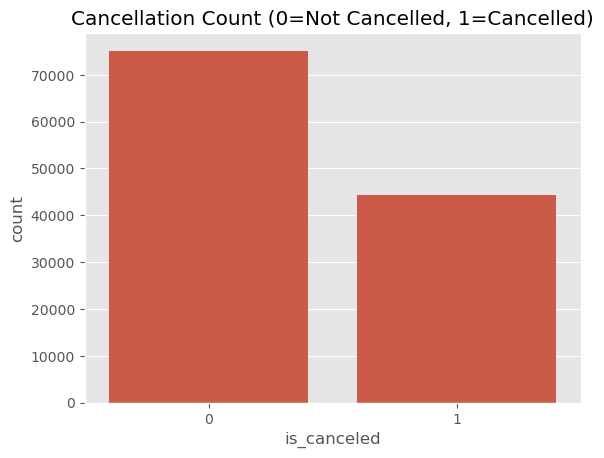

In [7]:
plt.style.use('ggplot')

# Cancellation distribution
sns.countplot(x='is_canceled', data=df)
plt.title('Cancellation Count (0=Not Cancelled, 1=Cancelled)')
plt.show()

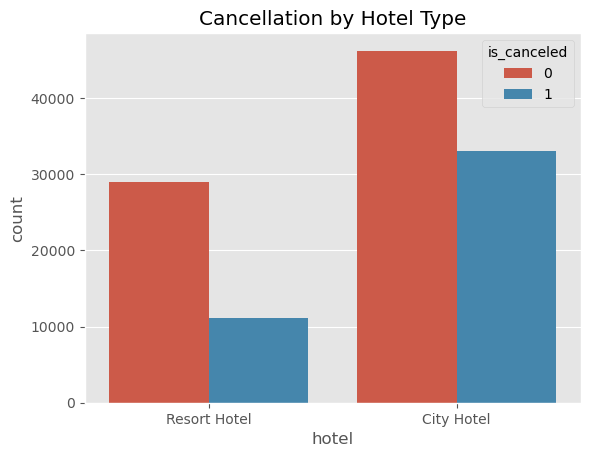

In [8]:
# Cancellation by hotel type
sns.countplot(x='hotel', hue='is_canceled', data=df)
plt.title('Cancellation by Hotel Type')
plt.show()

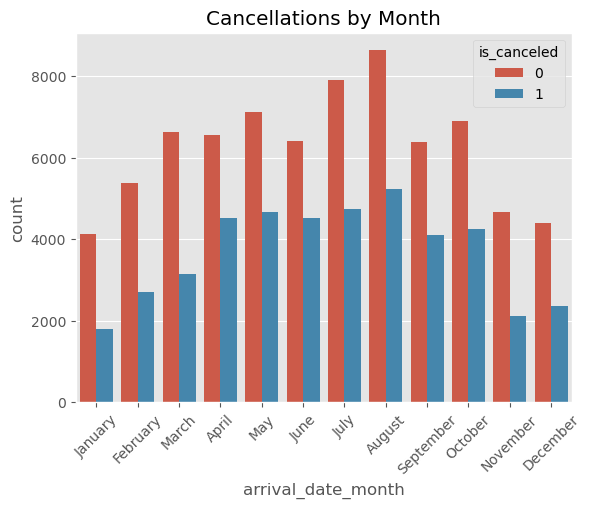

In [9]:
# Cancellation by month
month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
sns.countplot(x='arrival_date_month', hue='is_canceled', data=df, order=month_order)
plt.title('Cancellations by Month')
plt.xticks(rotation=45)
plt.show()

## 6. Feature Engineering

In [10]:
# Create new features
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_children'] = df['children']
if 'babies' in df.columns:
    df['total_children'] = df['children'] + df['babies']

# Drop date column (not needed for ML)
if 'reservation_status_date' in df.columns:
    df.drop('reservation_status_date', axis=1, inplace=True)

# One-hot encode categorical columns
df = pd.get_dummies(df, drop_first=True)
print("Shape after encoding:", df.shape)

Shape after encoding: (119390, 249)


## 7. Model Building

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = df.drop('is_canceled', axis=1)
y = df['is_canceled']
X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (95512, 248)
Test size: (23878, 248)


### 7.1 Logistic Regression

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=2000, solver='lbfgs')
log_model.fit(X_train_scaled, y_train)
y_pred_lr = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr, digits=4))

Logistic Regression Accuracy: 0.8185358907781222

Confusion Matrix:
 [[13651  1382]
 [ 2951  5894]]

Classification Report:
               precision    recall  f1-score   support

           0     0.8223    0.9081    0.8630     15033
           1     0.8101    0.6664    0.7312      8845

    accuracy                         0.8185     23878
   macro avg     0.8162    0.7872    0.7971     23878
weighted avg     0.8177    0.8185    0.8142     23878



### 7.2 Random Forest

In [13]:
rf_model = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, digits=4))

Random Forest Accuracy: 0.8880559510846805

Confusion Matrix:
 [[14173   860]
 [ 1813  7032]]

Classification Report:
               precision    recall  f1-score   support

           0     0.8866    0.9428    0.9138     15033
           1     0.8910    0.7950    0.8403      8845

    accuracy                         0.8881     23878
   macro avg     0.8888    0.8689    0.8771     23878
weighted avg     0.8882    0.8881    0.8866     23878



### 7.3 Feature Importance

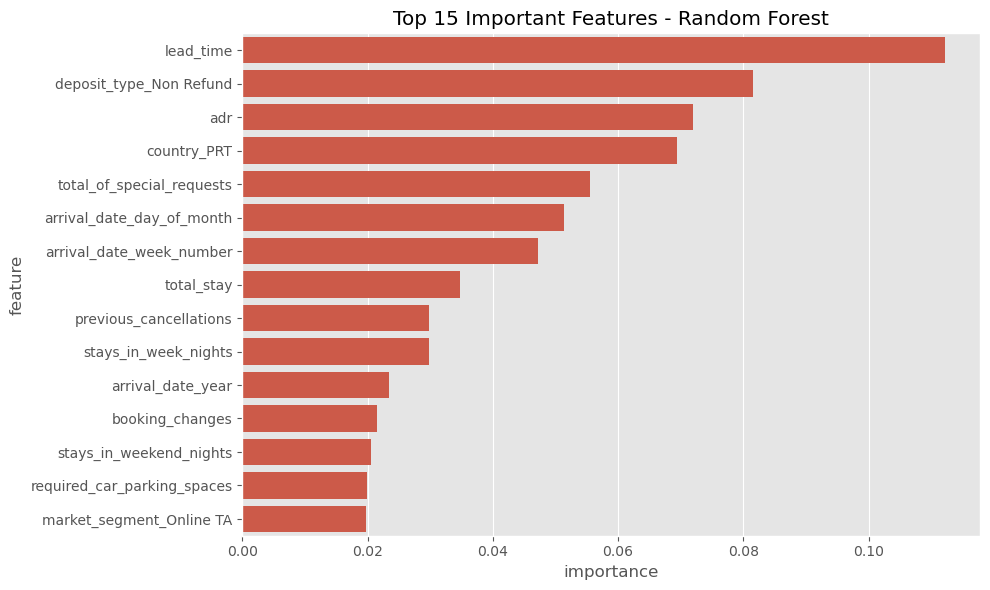

In [14]:
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({'feature': X.columns, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feat_imp)
plt.title('Top 15 Important Features - Random Forest')
plt.tight_layout()
plt.show()

## 8. Conclusion

- Analyzed hotel booking data to predict cancellations using machine learning
- Performed data cleaning, EDA, and feature engineering (total stay, total children)
- **Logistic Regression** achieved ~81.8% accuracy
- **Random Forest** achieved ~88.8% accuracy — selected as the final model
- Key factors influencing cancellations: **lead time, deposit type, ADR (price), and previous cancellations**
- This model can help hotels identify high-risk bookings early and reduce revenue loss